In [4]:
import os
import json
import importlib
import inspect
import argparse
import pandas as pd

from tqdm import tqdm
import matplotlib.pyplot as plt
from collections import OrderedDict

import numpy as np
import torch
from torch.utils.data import DataLoader

from import_model import import_model
from import_dataset import import_dataset

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [5]:
pt_to_inference = "train_sessions/EncoderDecoderTransformer_20250622_190339/EncoderDecoderTransformer_epoch001_val0.1834.pt"
json_to_inference = os.path.join(os.path.split(pt_to_inference)[0],"args.json")

In [7]:
with open(json_to_inference, 'r') as f:
    data = json.load(f)

args = argparse.Namespace(**data)

base_dataset_kwargs = { "coin_symbol": args.coin_symbol, "input_window": args.input_window, "output_window": args.output_window,
"augmentation_noise_std": args.augmentation_noise_std, "augment_constant_c": args.augment_constant_c, "augment_scale_s": args.augment_scale_s,
"z_norm_means_csv_path": args.z_norm_means_csv_path, "z_norm_stds_csv_path": args.z_norm_stds_csv_path,
"distribution_scale": args.distribution_scale, "distribution_clip": args.distribution_clip,
"output_distribution": args.output_distribution, "n_quantiles": args.n_quantiles}

inference_val_dataset_kwargs = {**base_dataset_kwargs, "csv_path": "../data/BTC_ETH_BNB_XRP_6h_log_returns_val.csv", "augmentation_p": 0, "transform":1}
inference_val_dataset = import_dataset(args.dataset_name, **inference_val_dataset_kwargs)
inference_val_loader = DataLoader(inference_val_dataset, batch_size=args.batch_size, shuffle=False)

model_kwargs = {"input_features": args.input_features, "output_features": args.output_features,
"input_window": args.input_window, "output_window": args.output_window,
"dropout": args.dropout, "num_layers": args.num_layers,
"hidden_dim": args.hidden_dim, "num_heads": args.num_heads,
"teacher_forcing_ratio": args.teacher_forcing_ratio,
"target_coin_index": args.target_coin_index,
"num_coins": args.num_coins, "device": device}

model = import_model(args.model_name, **model_kwargs)
model.load_state_dict(torch.load(pt_to_inference, weights_only=True))

<All keys matched successfully>

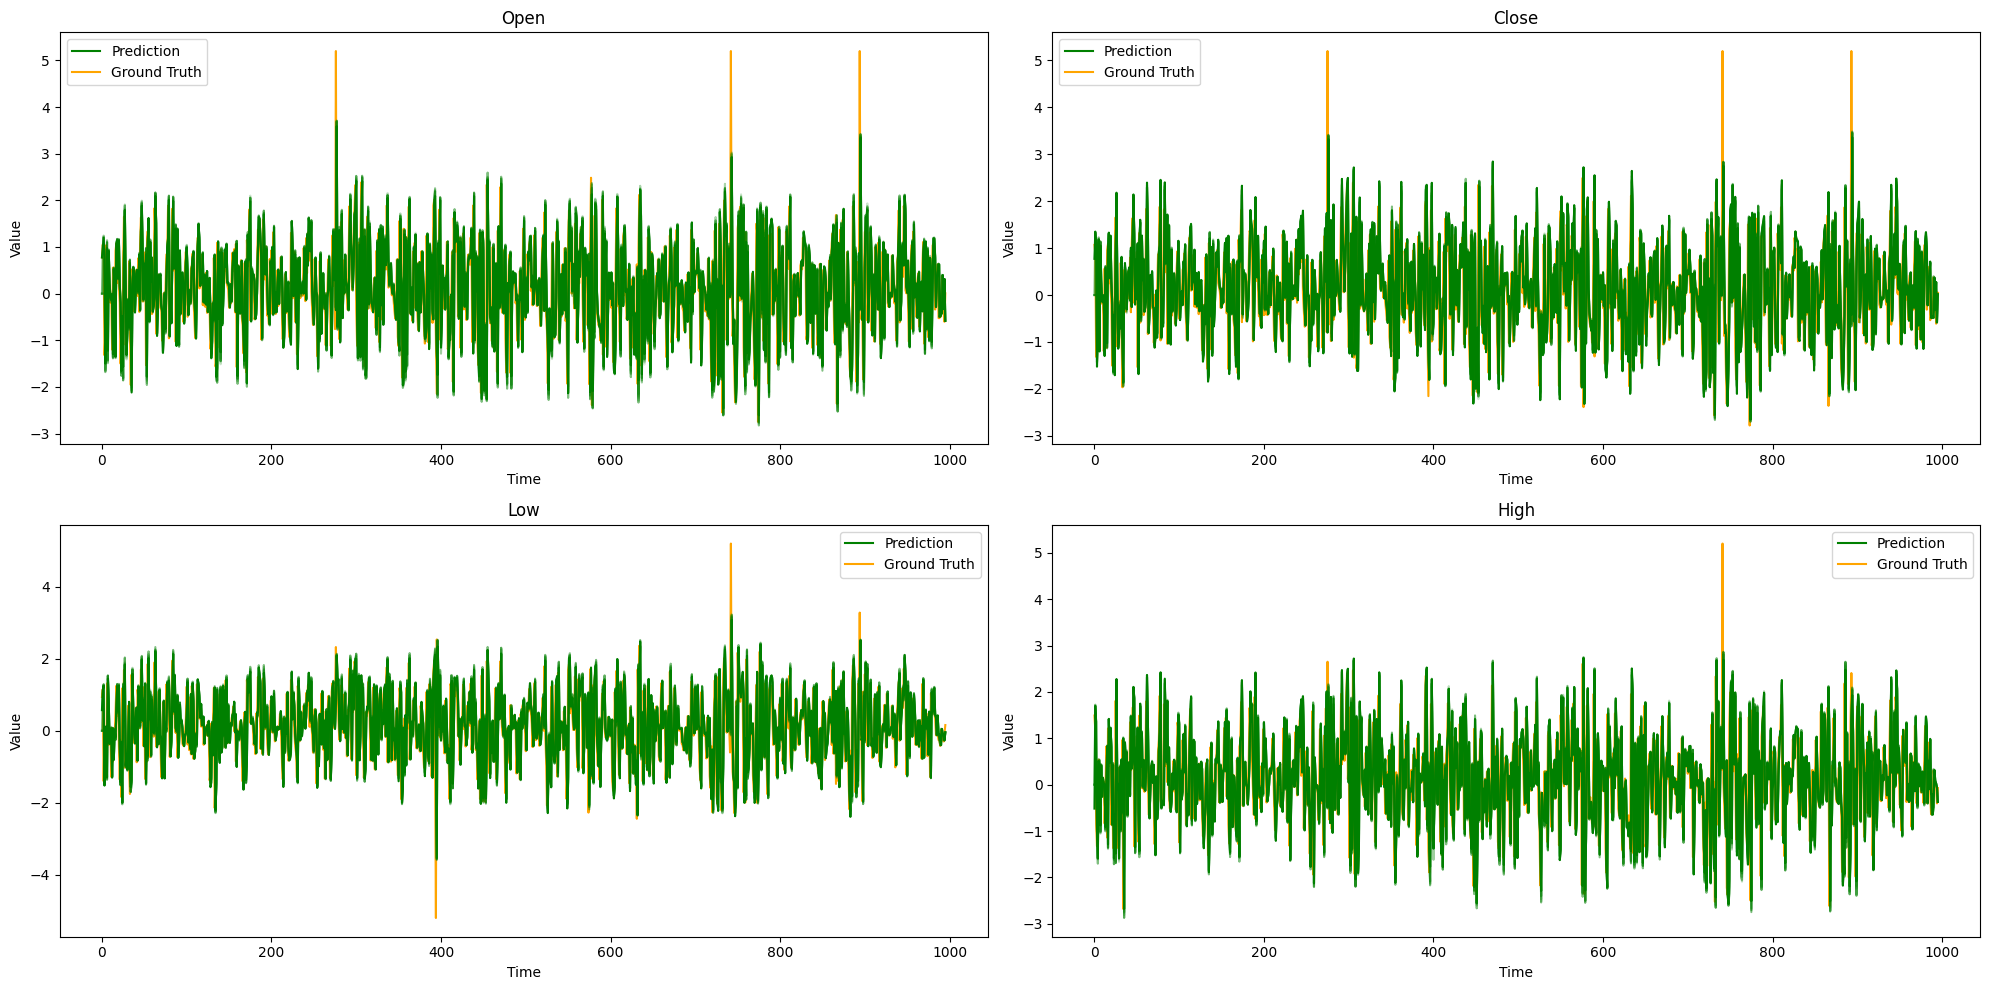

In [8]:
model = model.eval()
all_targets = []
all_predictions = []

with torch.no_grad():
    for x_batch, y_batch in tqdm(inference_val_loader, leave=False):
        x_batch = x_batch.to(device)
        y_batch = y_batch.to(device)

        preds = model.call(x_batch, y_batch)
        all_predictions.append(preds.cpu())
        all_targets.append(y_batch.cpu())

# Concatenate all batches [batch, 4, 8] -> [total_seq, 4, 8]
all_targets = torch.cat(all_targets, dim=0)  # [n, 4, 8]
all_predictions = torch.cat(all_predictions, dim=0)  # [n, 4, 8]

# Reshape into full time series: [n, 4, 8] -> [4, n, 8]
target_series = all_targets.permute(1, 0, 2)
pred_series = all_predictions.permute(1, 0, 2)

target_series_to_plot = torch.cat((target_series[:,:,0], target_series[:,-1]), dim=1)
pred_series_with_different_trusts = []
for trust in range(8):
    pred_series_with_different_trusts.append(torch.cat((torch.zeros(pred_series.shape[0], trust), pred_series[:,:,trust], pred_series[:,-1,trust:]), dim=1))

feature_names = ["Open", "Close", "Low", "High"]
plt.figure(figsize=(20, 10))

for i in range(4):
    plt.subplot(2, 2, i + 1)
    
    plt.plot(target_series_to_plot[i], label="Ground Truth", color="orange")
    for trust, pred_series_to_plot in enumerate(pred_series_with_different_trusts):
        plt.plot(pred_series_to_plot[i], label="Prediction", color="green", alpha=1/(trust+1))

    plt.title(f'{feature_names[i]}')
    plt.xlabel("Time")
    plt.ylabel("Value")
    plt.legend()

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(reversed(labels), reversed(handles)))
    plt.legend(by_label.values(), by_label.keys())    

plt.tight_layout()
plt.show()

In [ ]:
"""
1- get a train_directory path
2- read the json
3- recreate the training environment with the args
4- do the inference predictions
5- read the real dataset, get the initial price
6- re-scale the predicted prices
7- plot the price line
8- save the predicted dataframe as csv
"""